# Capstone - Refresh / Content Opportunity Scoring

This notebook mirrors the deployed research paper. It summarizes the real warehouse model, validation, limitations, and ranked action output.

## 1. Question

Which content items should a human reviewer inspect first because recent safe search/content signals suggest elevated risk of future impression decline?

The decision supported is prioritization: a strategist has limited review time and needs a ranked queue, not a yes/no automation.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "work" / "scripts" / "run_capstone_analysis.py").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root")

ROOT = find_repo_root(Path.cwd().resolve())
METRICS_PATH = ROOT / "work" / "outputs" / "capstone_metrics.json"
if not METRICS_PATH.exists():
    raise FileNotFoundError(
        "Missing work/outputs/capstone_metrics.json. Run `python work/scripts/run_capstone_analysis.py` from the repo root after Hugging Face login."
    )
metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
results = pd.DataFrame(metrics["results"])
top_features = pd.DataFrame(metrics["top_features"])
top20 = pd.DataFrame(metrics["top20_preview"])
print(f"Loaded metrics from {METRICS_PATH.relative_to(ROOT)}")
print(f"Eligible rows: {metrics['eligible_rows']:,}; clients: {metrics['eligible_clients']}; base rate: {metrics['base_rate']:.3f}")


Loaded metrics from work\outputs\capstone_metrics.json
Eligible rows: 24,547; clients: 18; base rate: 0.256


## 2. Data

Data source: `FlyRank/internship-warehouse` release `v20260703`.

Tables used: `fact_content_daily_performance`, `dim_content`, and `dim_clients`.

Feature window: August 1 through September 30, 2025. Target window: October 1 through October 31, 2025.

Excluded from features: October metrics, raw/private identifiers, URLs, queries, domains, and any product decision flags.

In [2]:
display(pd.DataFrame([{
    'release': metrics['release'],
    'feature_window': metrics['feature_window'],
    'target_window': metrics['target_window'],
    'eligible_rows': metrics['eligible_rows'],
    'eligible_clients': metrics['eligible_clients'],
    'base_rate': metrics['base_rate'],
}]))

,release,feature_window,target_window,eligible_rows,eligible_clients,base_rate
0,FlyRank/internship-warehouse v20260703,2025-08-01 through 2025-09-30; final feature m...,2025-10-01 through 2025-10-31,24547,18,0.2555


## 3. Methodology

Target: `future_decline_label = 1` when October 2025 impressions are less than 80% of September 2025 impressions.

Features come from August/September traffic, position, CTR, engagement, AI-session counts, metadata, and content age. Validation holds out whole clients. Baseline is the Week-4 `visible_low_ctr_page` rule.

In [3]:
display(pd.DataFrame({'leakage_exclusions': metrics['leakage_exclusions']}))

,leakage_exclusions
0,"June metrics are label/output only, not model ..."
1,trend_direction and trend_pct are not warehous...
2,IDs are used for grouping/splitting only
3,validation holds out whole clients


## 4. Results vs baseline

The selected random forest model substantially outperformed the visible-low-CTR baseline on the same held-out clients. This is a ranking result, not proof of causal refresh impact.

,method,roc_auc,avg_precision,precision_at_50,precision_at_100
0,logistic_regression,0.853186,0.729499,0.90,0.77
1,random_forest,0.871198,0.739586,0.90,0.78
2,baseline_visible_low_ctr,0.470689,0.258484,0.18,0.28


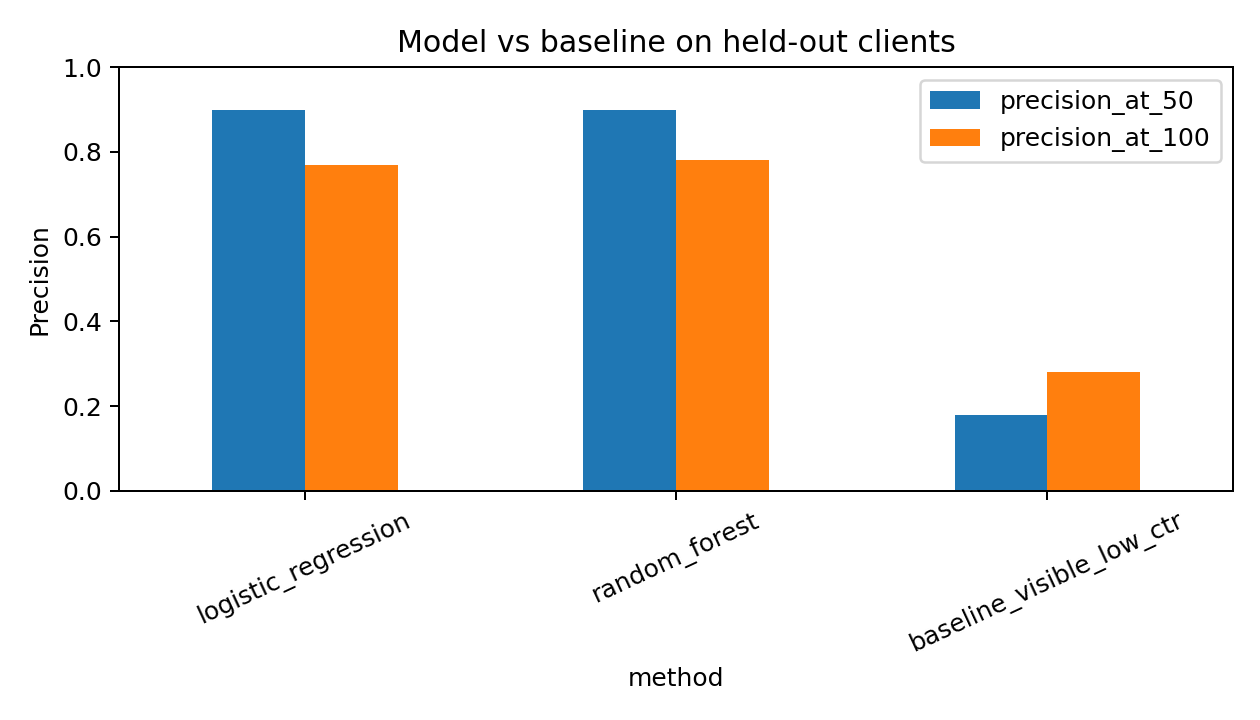

In [4]:
display(results)
Image(filename=str(ROOT / 'work' / 'figures' / 'capstone_model_vs_baseline.png'))

## 5. Limitations

This is an observational model on one warehouse slice. It cannot prove that editing a page will recover traffic, explain Google's ranking system, or replace human review. Some top-ranked pages are deep-position zero-click pages, which may be better monitor/prune candidates than refresh candidates.

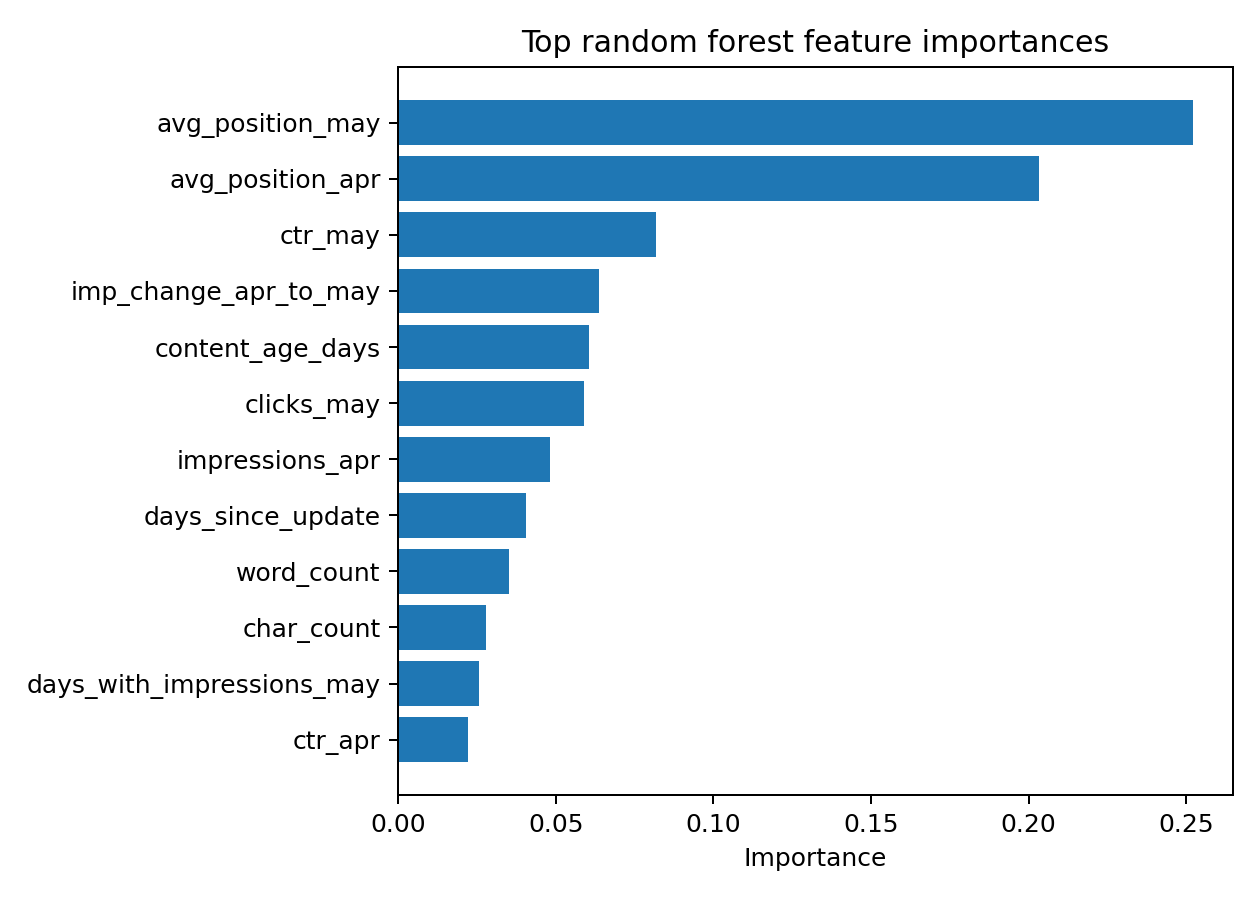

In [5]:
Image(filename=str(ROOT / 'work' / 'figures' / 'capstone_feature_importance.png'))

## 6. Ranked recommendations

The action queue prioritizes pages by blended model probability and baseline score, with reason codes. The top rows should be inspected before action.

In [6]:
display(top20[['rank','content_hash_id','final_action_score','action_label','reason_codes','impressions_may','ctr_may','avg_position_may','future_decline_label']].head(15))

,rank,content_hash_id,final_action_score,action_label,reason_codes,impressions_may,ctr_may,avg_position_may,future_decline_label
0,1,content_e5119f5ccb21b8be,69.31,monitor_or_prune,future_decline_risk;deep_zero_click_risk,256,0.0,80.734375,1
1,2,content_84332ce4be404e3f,69.27,monitor_or_prune,future_decline_risk;deep_zero_click_risk,306,0.0,76.669935,1
2,3,content_e02ca086a84cfd35,69.14,monitor_or_prune,future_decline_risk;deep_zero_click_risk,228,0.0,81.000000,1
3,4,content_ad0b68d1727295e3,69.11,monitor_or_prune,future_decline_risk;deep_zero_click_risk,304,0.0,82.569079,1
4,5,content_905103df18204769,69.10,monitor_or_prune,future_decline_risk;deep_zero_click_risk,263,0.0,75.041825,1
5,6,content_dcdb257bd5040270,69.09,monitor_or_prune,future_decline_risk;deep_zero_click_risk,241,0.0,84.514523,1
6,7,content_305afb885f6a3b9c,69.08,monitor_or_prune,future_decline_risk;deep_zero_click_risk,537,0.0,78.370577,1
7,8,content_df405a5ed66aab92,69.07,monitor_or_prune,future_decline_risk;deep_zero_click_risk,308,0.0,75.564935,1
8,9,content_7faa8052b9d6529d,69.06,monitor_or_prune,future_decline_risk;deep_zero_click_risk,375,0.0,84.600000,1
9,10,content_80be8e495d9ac06a,69.04,monitor_or_prune,future_decline_risk;deep_zero_click_risk,418,0.0,79.440191,1


## 7. Artifacts the paper embeds

The deployed page embeds the model-vs-baseline chart, feature-importance chart, action-mix chart, and a top recommendation table.

In [7]:
display(pd.DataFrame([metrics['outputs']]).T.rename(columns={0:'path'}))

,path
feature_table_csv,work/outputs/capstone_feature_table.csv
ranked_recommendations_csv,work/outputs/capstone_ranked_recommendations.csv
top20_csv,work/outputs/capstone_top20_recommendations.csv
model_vs_baseline_chart,work/figures/capstone_model_vs_baseline.png
feature_importance_chart,work/figures/capstone_feature_importance.png
action_mix_chart,work/figures/capstone_action_mix.png


## Self-check

- [x] Sections mirror the deployed research paper.
- [x] Data source and windows are named.
- [x] Baseline, model, validation, and leakage checks are included.
- [x] Claims use observed / directional / decision-support language.
- [x] No client names, domains, URLs, raw queries, or credentials appear.